# Exercise - Simple Linear Regression



In this notebook you can check your understanding of linear regression and implement a linear regression model with scikit-learn by yourself. 




## Learning Objectives



At the end of this notebook you should be able to 
- describe the relationship between two variables.
- train a linear regression model with scikit-learn.
- interpret the $R^2$ of a linear regression model.

## Question 1 



The scatter plots below show the relationship between height, diameter, and volume of timber in 31 felled black cherry trees. The diameter of the tree is measured 4.5 feet above the ground.  

<img src="images/lin_reg_ex_1.png" width="600">  

**(a) Describe the relationship between volume and height of these trees.**

There is a positive relationship between height and volume. As height increases, volume tends to increase as well. However, the relationship appears to be relatively weak, with a considerable amount of scatter in the data points.

**(b) Describe the relationship between volume and diameter of these trees.**

There is a strong positive linear relationship between diameter and volume. As the diameter increases, the volume increases significantly. The data points are closely clustered around a linear trend, indicating a strong association.

**(c) Suppose you measured the height and diameter of another black cherry tree. Which of these variables would be better for predicting the wood volume of this tree using a simple linear regression model? Explain your reasoning.**

Diameter would be a better predictor of wood volume. The relationship between diameter and volume is stronger and more linear compared to height. Therefore, a simple linear regression model using diameter would likely produce more accurate predictions.

## Question 2 

The file `utils.csv` in your data folder contains information about the average utility bills for homes of a particular size and the average monthly temperature.  

**(a) Load the data:**

In [2]:
import pandas as pd

utils = pd.read_csv("data/utils.csv")
utils.head()

,Month,Average Bill,Average Monthly Temperature
0,Jan,148.5,38
1,Feb,136.5,45
2,Mar,117.0,49
3,Apr,91.5,57
4,May,82.5,69


**(b) Make a scatter plot of the data average bill vs average monthly temperature. Which variable would make the most sense as the response variable?**

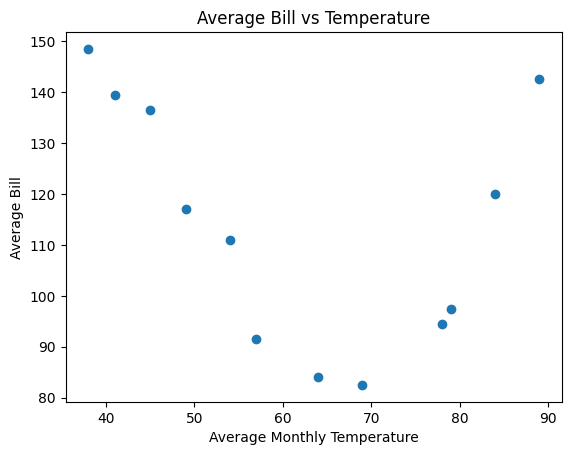

In [3]:
import matplotlib.pyplot as plt

plt.scatter(utils["Average Monthly Temperature"], utils["Average Bill"])
plt.xlabel("Average Monthly Temperature")
plt.ylabel("Average Bill")
plt.title("Average Bill vs Temperature")
plt.show()

The response variable should be the average bill, because the utility bill depends on the temperature. Temperature influences how much heating or cooling is needed, which affects the total utility cost.

**(c) Have a look at the plot above. How would you describe the relationship between the variables?** 

There appears to be a negative linear relationship between temperature and average bill. As the temperature increases, the average utility bill decreases. This suggests that colder months are associated with higher utility costs.

**(d) Train a simple linear regression model using scikit-learn**

In [4]:
from sklearn.linear_model import LinearRegression

X = utils[["Average Monthly Temperature"]]
y = utils["Average Bill"]

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**(e) Calculate and interpret the value of $R^2$.**  

In [5]:
r2 = model.score(X, y)
r2

0.12406543648691692

The R² value shows the proportion of variation in the average utility bill that is explained by temperature. A higher R² indicates that temperature explains a large part of the variation in utility costs.

**(f) Print the intercept and slope/coefficient and interpret them in terms a home owner would understand.**

In [6]:
intercept = model.intercept_
slope = model.coef_[0]
intercept, slope

(np.float64(143.62280506779285), np.float64(-0.4798844187597245))

The intercept represents the estimated utility bill when the temperature is 0 degrees.

The slope shows how much the average utility bill changes for each 1-degree increase in temperature. Since the slope is negative, the bill decreases as temperature increases.

**(g) Use your fitted model to estimate the average utility bill if the average monthly temperature is 120 degrees. Do you think that your answer is reasonable? Why or why not?** 

In [7]:
model.predict([[120]])

/Users/dmitriishumakher/Desktop/neuefische/ds-linear-regression/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([86.03667482])

The prediction for 120 degrees is not reasonable because this temperature is far outside the range of the observed data. This is an example of extrapolation, and linear models are unreliable when predicting far beyond the data range.